Change directory to "group04-team02-1"

### Generating pairwise alignment matrix per CDR region

In this notebook, similarity in CDR sequences between the three organisms SARS-CoV-2, Homo Sapiens and Influenza A is analyzed. In order to find groups of similar CDRs, a global alignment score must be defined. This score could help finding out if CDRs from the same organisms have a higher score among each other than the CDRs from two different organisms.
This notebook starts with a well-known but robust pairwise alignment.

Following code generates one file per CDR region comparing all pairs of sequences from all organisms.

This code reads in CDR sequence data for coronavirus, human, and influenza from separate TSV files. It adds an organism column to label the source of each sequence and then combines all three datasets into a single DataFrame called data. This combined dataset is used for downstream analyses that compare sequences across organisms.

In [51]:
import pandas as pd

# Load coronavirus data
corona = pd.read_csv(r'generated/cdrs/seq/corona_cdr_seq.tsv', sep="\t")
corona['organism'] = 'coronavirus'

# Load human data
human = pd.read_csv(r'generated/cdrs/seq/human_cdr_seq.tsv', sep='\t')
human['organism'] = 'human'

# Load influenza data
influenza = pd.read_csv(r'generated/cdrs/seq/influenza_cdr_seq.tsv', sep='\t')
influenza['organism'] = 'influenza'

# Combine all into one DataFrame
data = pd.concat([corona, human, influenza], ignore_index=True)

print("Combined data shape:", data.shape)
print("Organisms included:", data['organism'].unique())


Combined data shape: (961, 84)
Organisms included: ['coronavirus' 'human' 'influenza']


This code reads in CDR sequence data for coronavirus, human, and influenza from separate TSV files. It adds an organism column to label the source of each sequence and then combines all three datasets into a single DataFrame called data. This combined dataset is used for downstream analyses that compare sequences across organisms.
 
Then a global alignment score using pairwise2.align.globalxx from Biopython is computed, which counts the number of matching positions. The function pairwise2.align.globalxx(seq1, seq2) follows a very simple scoring scheme:
- Match = +1
- Mismatch = 0
- No gap penalties

Only non-null sequences are used for alignment, and the script compares every possible unique pair of sequences i and j.

Even though this alignment does not account for gap penalties, it does take into account sequence length differences, by aligning full sequences and normalizing scores.

It normalizes this raw score by dividing it by the alignment length, resulting in a similarity between 0 and 1. This facilitates the interpretation of the scores.

In [ ]:
from Bio import pairwise2

# Keeping only the relevant columns 
cdr_columns = ['CDR_H1', 'CDR_H2', 'CDR_H3', 'organism']
data_cdr = data[cdr_columns].copy()

print("Data columns used:", data_cdr.columns.tolist())
print("Number of sequences:", len(data_cdr))

# Truncate output files and write header line 
for cdr_column in ['CDR_H1', 'CDR_H2', 'CDR_H3']:
    with open(f'scores_{cdr_column}.txt', 'w') as f:
        f.write("i,j,org1,org2,normalized_score\n")

# Compute pairwise alignments
for cdr_column in ['CDR_H1', 'CDR_H2', 'CDR_H3']:
    print(f"\nProcessing {cdr_column}...")

    # Keep rows where this CDR is not null
    data_filtered = data_cdr[data_cdr[cdr_column].notnull()].reset_index(drop=True)

    # Iterate all pairs i<j
    for i in range(len(data_filtered)):
        for j in range(i + 1, len(data_filtered)):
            seq1 = data_filtered.loc[i, cdr_column]
            seq2 = data_filtered.loc[j, cdr_column]
            org1 = data_filtered.loc[i, 'organism']
            org2 = data_filtered.loc[j, 'organism']

            if isinstance(seq1, str) and isinstance(seq2, str):
                alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
                aln_seq1, aln_seq2, raw_score, start, end = alignments[0]
                alignment_length = len(aln_seq1)
                normalized_score = raw_score / alignment_length

                # Append result
                with open(f'scores_{cdr_column}.txt', 'a') as f:
                    f.write(f"{i},{j},{org1},{org2},{normalized_score:.4f}\n")


Data columns used: ['CDR_H1', 'CDR_H2', 'CDR_H3', 'organism']
Number of sequences: 961

Processing CDR_H1...


### Boxplot for visualization

To compare the pairwise similarity of sequences from the three CDRs, CDR_H1, CDR_H2, and CDR_H3 normalized similarity score files were loaded.  These normalized scores reflect how similar each pair of sequences is, with values closer to 1 indicating higher similarity.

These three datasets are combined into one DataFrame. A boxplot is generated using Seaborn to show the distribution of similarity scores per CDR region.
The visualization helps to quickly compare the general similarity tendencies across the three CDR types.

C:\Users\clara\AppData\Local\Temp\ipykernel_3252\4075510357.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_scores, x='CDR', y='normalized_score', palette='Set2')


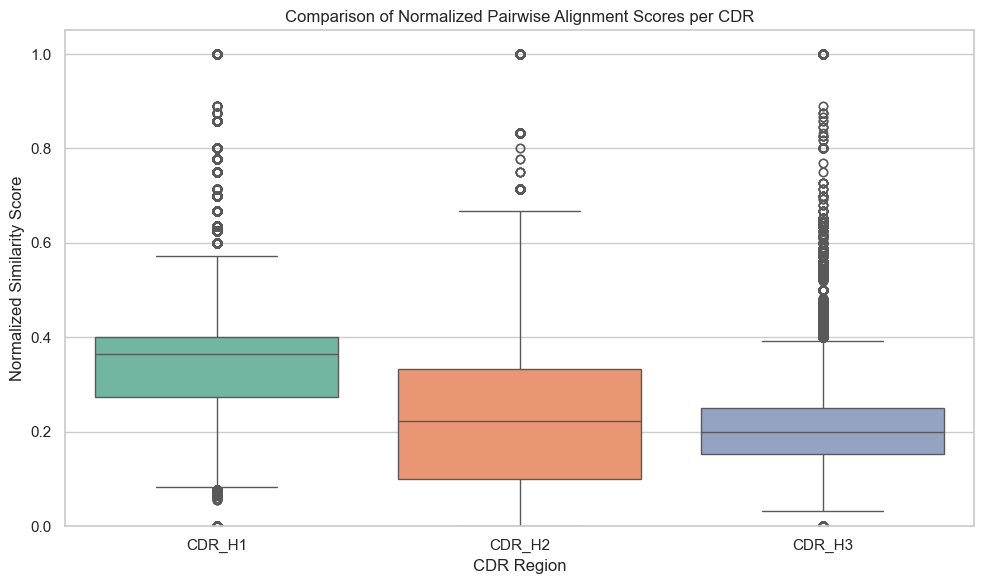

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the normalized score files
h1 = pd.read_csv('generated/cdrs/seq/scores_CDR_H1.txt')
h2 = pd.read_csv('generated/cdrs/seq/scores_CDR_H2.txt')
h3 = pd.read_csv('generated/cdrs/seq/scores_CDR_H3.txt')

# Add CDR type for identification
h1['CDR'] = 'CDR_H1'
h2['CDR'] = 'CDR_H2'
h3['CDR'] = 'CDR_H3'

# Combine into a single DataFrame
all_scores = pd.concat([h1, h2, h3], ignore_index=True)

# Set up the plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Boxplot to show score distribution
sns.boxplot(data=all_scores, x='CDR', y='normalized_score', palette='Set2')

# Formatting
plt.title('Comparison of Normalized Pairwise Alignment Scores per CDR')
plt.ylabel('Normalized Similarity Score')
plt.xlabel('CDR Region')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()



The results show that CDR_H1 exhibits the highest median similarity score, with a relatively narrow distribution. This suggests that sequences in this region could be more conserved. CDR_H2 shows a  lower median score and a broader distribution, indicating more variability compared to CDR_H1.

CDR_H3 displays the lowest median similarity score and the widest spread of values. The low similarity scores and outliers suggests variability within this region. 

### Conservation per position

Overall, the results above support the expected hierarchy of sequence variability across the CDRs.
Nevertheless, this is not necessarily biologically relevant. Higher similarity scores may be simply due to sequences being of the same or similar length, not necessarily due to conserved residues. This is crucial for further analysis. 

In this part, the goal was to investigate how differences in sequence length relate to pairwise similarity between CDRs. In other words, the relationship between sequence length difference and normalized similarity score was explored for the three heavy chain CDR regions: CDR_H1, CDR_H2, and CDR_H3.

Firstly, the similarity score matrices for each CDR, containing pairwise similarity scores and the corresponding sequence indices (i and j), were loaded. The CDR sequences from the three different sources (coronavirus, human, and influenza) were loaded as well in order to compute the lengths of each CDR applying the len() function to the sequence strings.

For each CDR (CDR_H1, CDR_H2, and CDR_H3), the following steps were carried out:
- The lengths of the sequences corresponding to each pair (i, j) were extracted.
- The absolute difference in length between the two sequences (|len_i - len_j|) was calculated and stored as len_diff.
- A scatter plot was then created, with the length difference on the x-axis and the normalized similarity score on the y-axis.

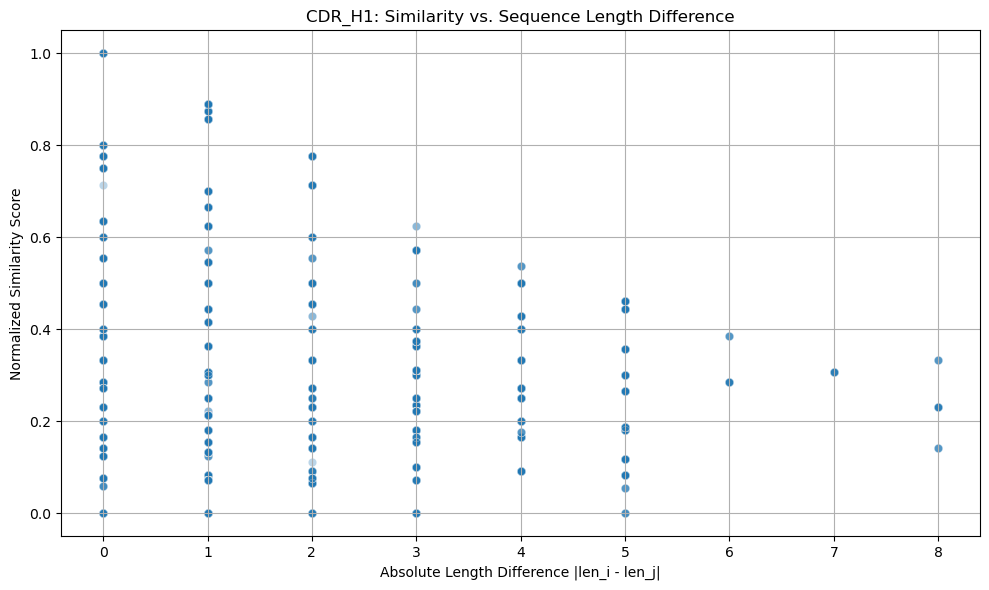

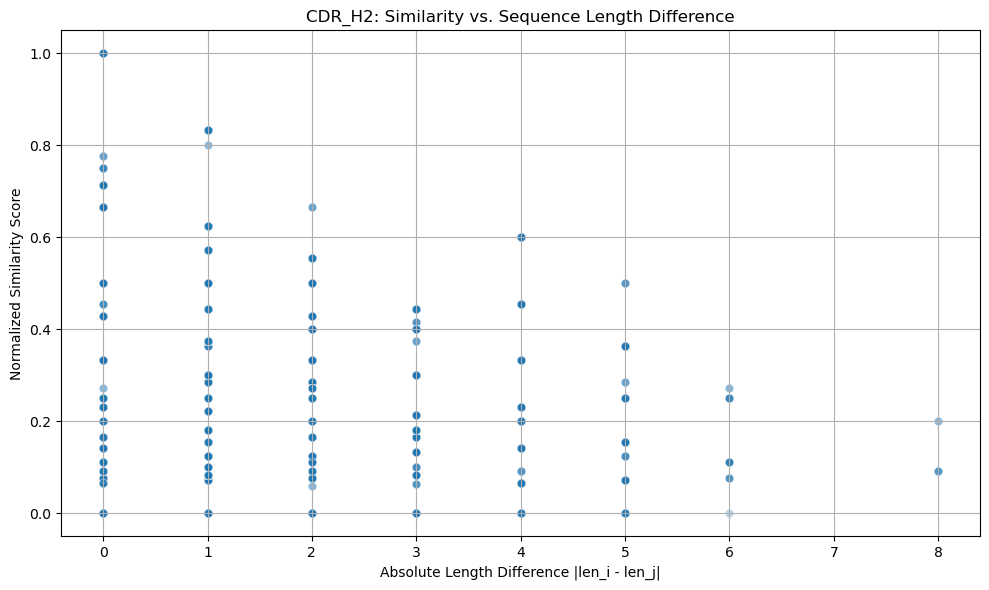

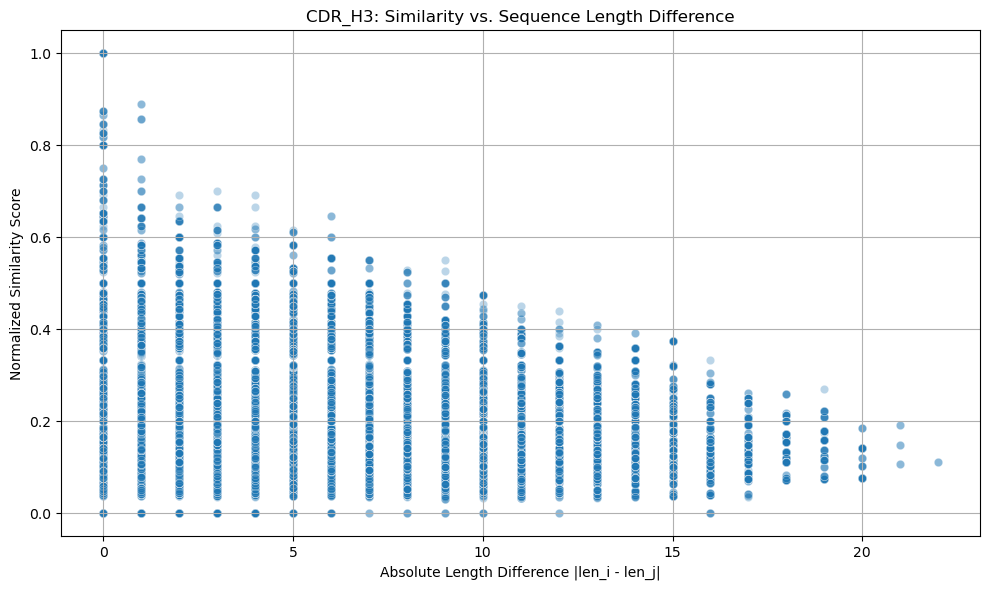

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all scores
CDR_scores = {
    "CDR_H1": pd.read_csv("generated/cdrs/seq/scores_CDR_H1.txt", sep=","),
    "CDR_H2": pd.read_csv("generated/cdrs/seq/scores_CDR_H2.txt", sep=","),
    "CDR_H3": pd.read_csv("generated/cdrs/seq/scores_CDR_H3.txt", sep=",")
}

# Load sequences
corona = pd.read_csv("generated/cdrs/seq/corona_cdr_seq.tsv", sep="\t")
human = pd.read_csv("generated/cdrs/seq/human_cdr_seq.tsv", sep="\t")
influenza = pd.read_csv("generated/cdrs/seq/influenza_cdr_seq.tsv", sep="\t")

# Combine all sequences and reset index
combined = pd.concat([corona, human, influenza], ignore_index=True)

# Compute lengths for each CDR
cdr_lengths = {}
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    lengths = combined[cdr].fillna("").apply(len)
    cdr_lengths[cdr] = lengths

# Plot similarity vs. length difference for each CDR
for cdr_name, df in CDR_scores.items():
    lengths = cdr_lengths[cdr_name]
    
    # Add length info to each pair
    df["len_i"] = df["i"].apply(lambda x: lengths.iloc[x])
    df["len_j"] = df["j"].apply(lambda x: lengths.iloc[x])
    df["len_diff"] = (df["len_i"] - df["len_j"]).abs()

    # Plot
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df, x="len_diff", y="normalized_score", alpha=0.3)
    plt.title(f"{cdr_name}: Similarity vs. Sequence Length Difference")
    plt.xlabel("Absolute Length Difference |len_i - len_j|")
    plt.ylabel("Normalized Similarity Score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


The purpose of these scatter plots is to visualize whether pairs of sequences with more similar lengths tend to have higher similarity scores. 
In these scatter plots, a trend is present. Sequences of equal or similar length align better, scoring higher, which becomes clear with the downward pattern in the scatter.
This means that as the length difference grows, alignment quality tends to drop, even if the sequences are otherwise similar. This is reflected in lower normalized scores, highlighting the sensitivity of alignment to insertions or deletions.
Furthermore, CDR H3 stands out for having the steepest decline. This could be because CDR H3 is more variable in both length and composition compared to CDR H1 and CDR H2. This leads to lower alignment scores.

In [46]:
# Compute lengths for each CDR
cdr_lengths = {
    cdr: combined[cdr].fillna("").apply(len)
    for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]
}
# For collecting correlations
correlations = {}

# Process each CDR
for idx, (cdr_name, df) in enumerate(CDR_scores.items()):
    lengths = cdr_lengths[cdr_name]
    
    # Add lengths and length difference
    df["len_i"] = df["i"].apply(lambda x: lengths.iloc[x])
    df["len_j"] = df["j"].apply(lambda x: lengths.iloc[x])
    df["len_diff"] = (df["len_i"] - df["len_j"]).abs()

    # Compute correlation
    corr = df["normalized_score"].corr(df["len_diff"])
    correlations[cdr_name] = corr
    

# Print correlation values
print("\n Correlation between similarity and length difference:")
for k, v in correlations.items():
    print(f"{k}: r = {v:.2f}")


 Correlation between similarity and length difference:
CDR_H1: r = -0.28
CDR_H2: r = -0.10
CDR_H3: r = -0.19


The correlation values between similarity score and length difference reveal a moderate but consistent negative relationship across all three CDRs. This means that as the difference in sequence length increases, the similarity score tends to decrease. Shortly: length differences contribute to lower similarity. 

CDR_H1 shows a moderate negative correlation (Person correlation r = -0.28), suggesting that sequence length differences have a moderate impact on alignment scores in this region.

This confirms the idea that when analyzing similarity in CDR sequences, sequence length is a biologically meaningful factor.

In conclusion, the pairwise alignment results relatively confirm expectations: CDR H3 sequences tend to show lower similarity scores than CDR H1 and H2, reflecting their known structural and functional diversity. 
While the global alignment approach provides a general overview, the latest tests suggest that an alternative algorithm might yield more accurate or meaningful results, especially for highly variable regions like CDR H3.